In [1]:
import numpy as np
import pandas as pd

In [4]:
df = pd.read_csv('placement.csv')
df

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0
...,...,...,...,...
95,95,4.3,200.0,0
96,96,4.4,42.0,0
97,97,6.7,182.0,1
98,98,6.3,103.0,1


In [5]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [7]:
df = df.iloc[:,1:]

In [8]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [9]:
import matplotlib.pyplot as plt


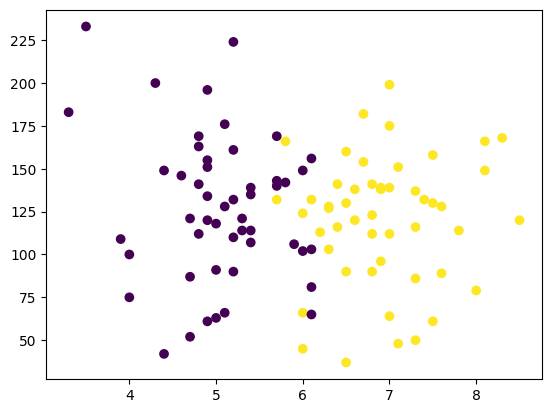

In [11]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [12]:
x = df.iloc[:,:2]
y = df.iloc[:,-1]


In [13]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [14]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [19]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1)


In [20]:
x_train

,cgpa,iq
47,5.2,161.0
64,7.0,64.0
31,3.9,109.0
1,5.9,106.0
4,5.8,142.0
...,...,...
54,6.4,141.0
18,4.0,100.0
28,5.2,90.0
46,5.3,114.0


In [21]:
x_test

,cgpa,iq
96,4.4,42.0
16,5.2,224.0
2,5.3,121.0
58,8.0,79.0
5,7.1,48.0
25,5.0,91.0
61,7.3,137.0
22,4.9,120.0
94,4.7,52.0
27,6.0,124.0


In [22]:
y_train

,placement
47,0
64,1
31,0
1,0
4,0
...,...
54,1
18,0
28,0
46,0


In [25]:
from sklearn.preprocessing import StandardScaler

In [26]:
scaler = StandardScaler()

In [27]:
x_train = scaler.fit_transform(x_train)

In [28]:
x_train

array([[-0.7195668 ,  0.93875111],
       [ 0.87291711, -1.64651614],
       [-1.86969407, -0.44716535],
       [-0.10026751, -0.52712207],
       [-0.18873883,  0.43235855],
       [-0.27721016,  0.16583616],
       [-1.07345212,  0.40570631],
       [-0.27721016,  0.37905407],
       [ 1.84610172,  1.0720123 ],
       [ 1.31527375,  0.85879439],
       [-0.7195668 , -0.42051311],
       [-0.98498079,  0.67222871],
       [ 0.43056047,  0.11253168],
       [ 1.31527375, -1.72647285],
       [ 0.16514648, -0.34055639],
       [ 0.25361781,  0.03257496],
       [-0.89650946, -0.2072952 ],
       [-2.40052204,  1.52510038],
       [ 0.07667515,  0.80548991],
       [-0.80803813,  1.3385347 ],
       [-0.18873883,  1.0720123 ],
       [-0.80803813, -1.59321166],
       [ 1.84610172,  0.61892423],
       [-1.16192345, -0.12733848],
       [-0.89650946, -1.67316838],
       [ 0.78444578, -0.79364447],
       [ 1.13833109, -2.01964749],
       [ 0.51903179, -0.15399072],
       [ 0.69597445,

In [29]:
x_test = scaler.transform(x_test)

In [30]:
x_test

array([[-1.42733743, -2.23286541],
       [-0.7195668 ,  2.6178422 ],
       [-0.63109548, -0.12733848],
       [ 1.75763039, -1.24673254],
       [ 0.96138844, -2.07295197],
       [-0.89650946, -0.92690567],
       [ 1.13833109,  0.29909736],
       [-0.98498079, -0.15399072],
       [-1.16192345, -1.96634301],
       [-0.01179618, -0.04738176]])

In [31]:
from sklearn.linear_model import LogisticRegression

In [37]:
clf = LogisticRegression()

In [38]:
clf.fit(x_train,y_train)

LogisticRegression()

In [41]:
y_pred = clf.predict(x_test)

In [40]:
y_test

,placement
96,0
16,0
2,0
58,1
5,1
25,0
61,1
22,0
94,0
27,1


In [46]:
from sklearn.metrics import accuracy_score

In [43]:
accuracy_score(y_test,y_pred)

1.0

In [50]:
from mlxtend.plotting import plot_decision_regions

In [53]:
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions

<Axes: >

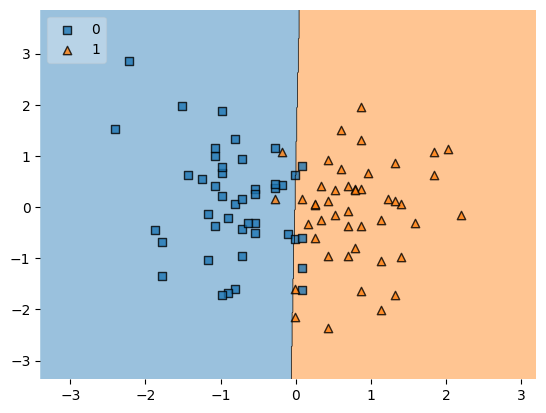

In [60]:
plot_decision_regions(x_train,y_train.values,clf=clf,legend=2)

In [61]:
import pickle

In [62]:
pickle.dump(clf,open('model.pkl','wb'))